# Case Study 1: Customer Churn Prediction (Logistic Regression)
Dataset: IBM Telco Customer Churn

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset (stored locally in this repo under data/)
df = pd.read_csv("data/Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nInformation:")
df.info()

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Information:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity  

In [3]:
# TotalCharges is loaded as text due to blank strings for new customers; convert to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

# A handful of new customers (tenure=0) have blank TotalCharges -> drop those rows
df = df.dropna(subset=["TotalCharges"])
print("\nShape after dropping missing TotalCharges rows:", df.shape)

Missing values:
TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

Duplicate rows: 0

Shape after dropping missing TotalCharges rows: (7032, 21)


Target distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64


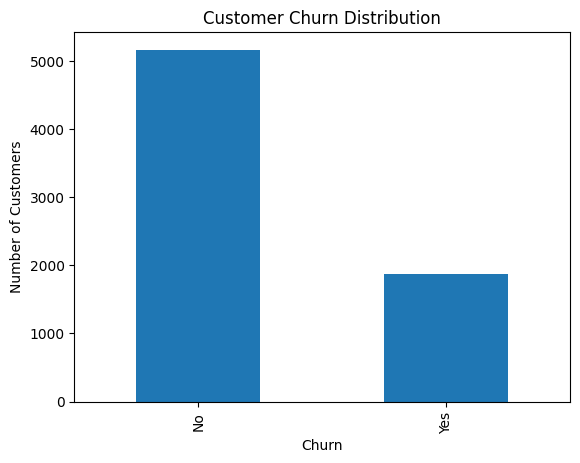

In [5]:
TARGET = "Churn"

print("Target distribution:")
print(df[TARGET].value_counts())

df[TARGET].value_counts().plot(kind="bar")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

In [6]:
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])
    print("Shape:", df.shape)

Shape: (7032, 20)


In [7]:
# Convert binary target to 0/1
df[TARGET] = df[TARGET].map({"No": 0, "Yes": 1})

# One-hot encode categorical features
df = pd.get_dummies(df, columns=df.select_dtypes(include="object").columns, drop_first=True)
df.shape

/tmp/ipykernel_141/771314738.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df = pd.get_dummies(df, columns=df.select_dtypes(include="object").columns, drop_first=True)


(7032, 31)

In [8]:
df.head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [9]:
X = df.drop(TARGET, axis=1)
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (7032, 30)
y shape: (7032,)
Churn
0    5163
1    1869
Name: count, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training:", X_train_scaled.shape)
print("Testing :", X_test_scaled.shape)

Training: (5625, 30)
Testing : (1407, 30)


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("Training completed")
print("Regularization: L2")
print("C:", model.C)

Training completed
Regularization: L2
C: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [12]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Churn Probability": y_prob
})

results.head(20)

,Actual,Predicted,Churn Probability
0,0,0,0.017115
1,0,1,0.596132
2,0,0,0.004764
3,1,0,0.200044
4,0,0,0.100222
5,1,0,0.470029
6,0,0,0.026611
7,0,0,0.164149
8,1,1,0.686141
9,0,0,0.015180


In [13]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, zero_division=0))
print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
print("F1-score :", f1_score(y_test, y_pred, zero_division=0))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy : 0.8038379530916845
Precision: 0.6475903614457831
Recall   : 0.5748663101604278
F1-score : 0.6090651558073654
ROC-AUC  : 0.8356727976766699

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



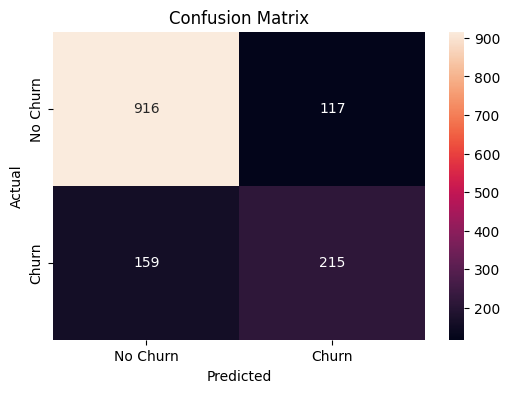

In [14]:
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
C_values = [0.01, 0.1, 1, 10, 100]
rows = []

for C in C_values:
    m = LogisticRegression(
        penalty="l2",
        C=C,
        max_iter=1000,
        random_state=42
    )
    m.fit(X_train_scaled, y_train)
    pred = m.predict(X_test_scaled)
    prob = m.predict_proba(X_test_scaled)[:,1]

    rows.append({
        "C": C,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, prob)
    })

pd.DataFrame(rows)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to it

,C,Accuracy,Precision,Recall,F1,ROC-AUC
0,0.01,0.798152,0.646104,0.532086,0.583578,0.833095
1,0.10,0.803838,0.650307,0.566845,0.605714,0.835072
2,1.00,0.803838,0.647590,0.574866,0.609065,0.835673
3,10.00,0.800284,0.638806,0.572193,0.603667,0.835184
4,100.00,0.796731,0.631737,0.564171,0.596045,0.834832
